# Morningstar DBRS — Quantitative Research: Technical Interview Test
**Léo Fabreguès**


In [1]:
import numpy as np
from scipy import stats
from scipy.stats import norm, multivariate_normal
from scipy.optimize import brentq
import matplotlib.pyplot as plt

## Part 1 Monte Carlo Gaussian Factor Model

Each loan $i$ has standardised asset return:
$$Z_i = \mathbf{w}_i^\top \mathbf{F} + b_i\,\varepsilon_i, \qquad b_i = \sqrt{1 - \|\mathbf{w}_i\|^2}$$
where $\mathbf{F} \sim \mathcal{N}(\mathbf{0}, I_d)$ are the systematic factors and $\varepsilon_i \sim \mathcal{N}(0,1)$ is idiosyncratic,  so that $Z_i \sim \mathcal{N}(0,1)$ marginally. 

The loan default condition is $Z_i < \Phi^{-1}(p_i)$ for some $i$. 
We process `batch_size` scenarios at a time, keeping peak RAM within $O(\text{batch} \times n \times 8 \text{ bytes}) = O(\text{batch} \times n)$.


In [2]:
class GaussianFactorMC:
    """
    Parameters
    ead : array-like (n,)
        Exposure at default.
    lgd : array-like (n,)
        Loss given default in [0,1].
    pd : array-like (n,)
        Unconditional default probability in ]0,1[.
    factor_weights : array-like (n,) or (n,d)
        Factor loading matrix W; row i = w_i, with ||w_i||^2 < 1.
    n_simulations : int
        Number of Monte Carlo scenarios.
    seed : int or None
        Random seed for reproducibility.
    batch_size : int
        Scenarios per memory batch (auto-capped to roughly 400 MB).
    """

    def __init__(self, ead, lgd, pd, factor_weights, n_simulations=100_000, seed=None):
        self.ead = np.asarray(ead, dtype=float)
        self.lgd = np.asarray(lgd, dtype=float)
        self.pd  = np.asarray(pd,  dtype=float)

        W = np.asarray(factor_weights, dtype=float)
        if W.ndim == 1:
            W = W[:, np.newaxis]
        self.W = W
        self.n, self.d = W.shape

        factor_loading_norm = np.sum(self.W ** 2, axis=1)
        if np.any(factor_loading_norm >= 1.0):
            raise ValueError("||w_i||^2 must be < 1 for all loans.") #required by the document
        self.b = np.sqrt(1.0 - factor_loading_norm)  # idiosyncratic weight

        self.thresholds = norm.ppf(self.pd) #compute c_i = Phi^{-1}(p_i)
        self.loss_weights = self.ead * self.lgd #precompute EAD_i * LGD_i for all loans

        self.n_simulations = n_simulations
        self.rng = np.random.default_rng(seed)
        #Batch size computed internally to keep peak RAM under ~400 MB.
        #Two (batch x n) float64 arrays cost 2 * batch * n * 8 bytes.
        self.batch_size = max(1, int(400e6 / (2 * self.n * 8)))

        self.loss_samples = None #initialization
        self.default_samples = None #initialization

    def run(self):
        """Simulate and store results"""
        n_sim = self.n_simulations
        losses = np.empty(n_sim, dtype=float)
        n_defaults = np.empty(n_sim, dtype=np.int32)

        processed = 0
        while processed < n_sim:
            bs = min(self.batch_size, n_sim - processed)
            #systematic factors and idiosyncratic shocks for this batch
            F = self.rng.standard_normal((bs, self.d))
            eps = self.rng.standard_normal((bs, self.n))
            Z = F @ self.W.T + self.b * eps
            defaults = Z < self.thresholds  #default condition of a loan

            losses[processed:processed + bs] = defaults @ self.loss_weights
            n_defaults[processed:processed + bs] = defaults.sum(axis=1)
            processed = processed + bs

        self.loss_samples = losses
        self.default_samples = n_defaults

    def statistics(self):
        """
        Return a dictionary of summary statistics:
          loss_mean, loss_var, default_mean, default_var,
          loss_VaR_{q} and default_VaR_{q} for q in {0.75, 0.90, 0.95, 0.99}.
        Variances use ddof=1 (unbiased estimator).
        """
        if self.loss_samples is None:
            raise RuntimeError("Call run() before accessing results.")
        quantiles = [0.75, 0.90, 0.95, 0.99]
        out = {
            "loss_mean" : float(self.loss_samples.mean()),
            "loss_var" : float(self.loss_samples.var(ddof=1)),
            "default_mean" : float(self.default_samples.mean()),
            "default_var" : float(self.default_samples.var(ddof=1)),
        }
        for q in quantiles:
            out[f"loss_VaR_{q}"] = float(np.quantile(self.loss_samples,    q))
            out[f"default_VaR_{q}"] = float(np.quantile(self.default_samples, q))
        return out

    def plot_distributions(self, title_suffix=""):
        """Histograms of default count and portfolio loss with VaR lines."""
        if self.loss_samples is None:
            raise RuntimeError("Call run() before accessing results.")
        quantiles = [0.75, 0.90, 0.95, 0.99]
        colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Loss & Default Distributions" + (f" for {title_suffix}" if title_suffix else ""), fontsize=13)

        #Default count histogram
        ax = axes[0]
        ax.hist(self.default_samples, bins=60, density=True, color="steelblue", alpha=0.7, edgecolor="white")
        for q, col in zip(quantiles, colors):
            v = float(np.quantile(self.default_samples, q))
            ax.axvline(v, color=col, linestyle="--", linewidth=1.5, label=f"VaR {int(q*100)}% = {v:.0f}")
        ax.set_xlabel("Number of defaults")
        ax.set_ylabel("Density")
        ax.set_title("Default count distribution")
        ax.legend(fontsize=8)

        #Portfolio loss histogram
        ax = axes[1]
        ax.hist(self.loss_samples, bins=60, density=True, color="darkorange", alpha=0.7, edgecolor="white")
        for q, col in zip(quantiles, colors):
            v = float(np.quantile(self.loss_samples, q))
            ax.axvline(v, color=col, linestyle="--", linewidth=1.5, label=f"VaR {int(q*100)}% = {v:.4f}")
        ax.set_xlabel("Portfolio loss")
        ax.set_ylabel("Density")
        ax.set_title("Portfolio loss distribution")
        ax.legend(fontsize=8)

        plt.tight_layout()
        return fig

### Tasks 1.1 to 1.3 Validation on a homogeneous portfolio

For a homogeneous portfolio ($\text{EAD}_i = 1/n$, uniform LGD, uniform PD) we have
$$\mathbb{E}[L] = \text{LGD} \times p = 0.45 \times 0.05 = 0.0225$$
The MC mean should match this to within $\approx 0.2\%$ for $N_{\text{sim}} = 100{,}000$.


Validation of Homogeneous portfolio for (n=1,000, rho=0.15)
Analytical E[L] = 0.022500
MC E[L] = 0.022423
Relative error = 0.340%

E[N_D] = 49.83  (expected ~ 50)
  loss_VaR_0.75 = 0.030150
  loss_VaR_0.9 = 0.048150
  loss_VaR_0.95 = 0.062100
  loss_VaR_0.99 = 0.095400


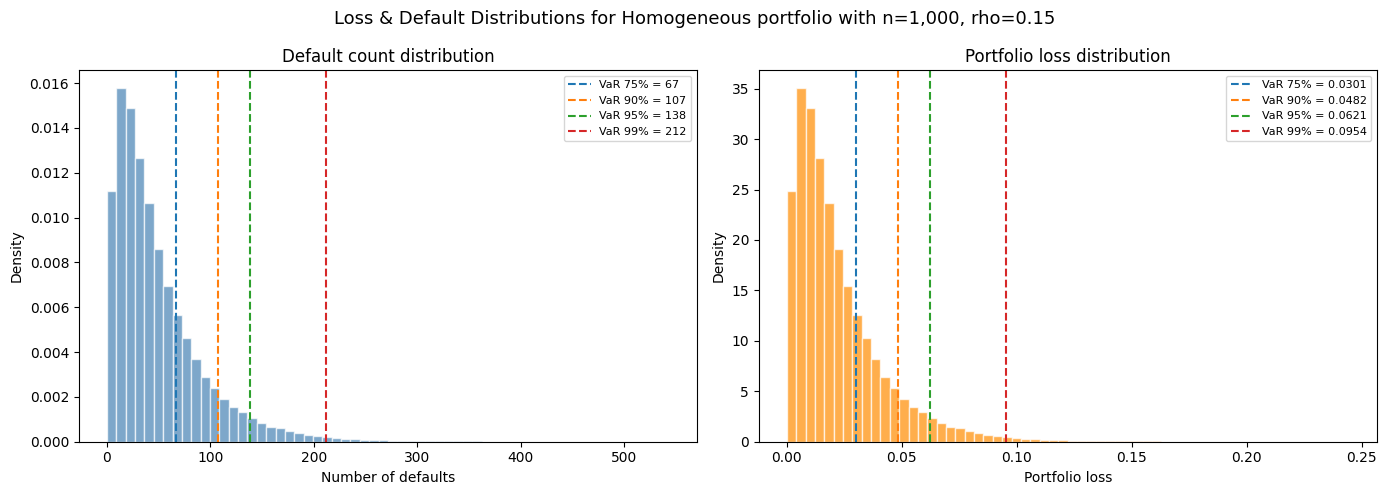

In [3]:
n = 1_000
p = 0.05
rho = 0.15
lgd = 0.45

mc = GaussianFactorMC(
    ead=np.full(n, 1/n),
    lgd=np.full(n, lgd),
    pd=np.full(n, p),
    factor_weights=np.full((n, 1), np.sqrt(rho)),
    n_simulations=100_000,
    seed=42,
)
mc.run()

analytical_el = lgd * p #analytical expected loss formula
s = mc.statistics()

print(f"Validation of Homogeneous portfolio for (n={n:,}, rho={rho})")
print(f"Analytical E[L] = {analytical_el:.6f}")
print(f"MC E[L] = {s['loss_mean']:.6f}")
print(f"Relative error = {abs(s['loss_mean']- analytical_el)/ analytical_el*100:.3f}%")
print(f"\nE[N_D] = {s['default_mean']:.2f}  (expected ~ {n*p:.0f})")
for q in [0.75, 0.90, 0.95, 0.99]:
    print(f"  loss_VaR_{q} = {s[f'loss_VaR_{q}']:.6f}")

fig = mc.plot_distributions(title_suffix=f"Homogeneous portfolio with n={n:,}, rho={rho}")
plt.show()

### Scenarios (a)–(d)


In [4]:
p = 0.05
rho = 0.15
lgd = 0.45
rng = np.random.default_rng(0)
n_sim = 50_000

#(a) Portfolio size
#By the Law of Large Numbers, as n increases the idiosyncratic component
#diversifies away and the loss distribution concentrates around the systematic
#factor. Hence Var[L] and VaR99 decrease with n, converging to the Vasicek limit.
print("Scenario (a): Portfolio size")
for n in [10, 100, 1_000, 10_000]:
    mc = GaussianFactorMC(
        ead=np.full(n, 1/n), lgd=np.full(n, lgd), pd=np.full(n, p),
        factor_weights=np.full((n, 1), np.sqrt(rho)),
        n_simulations=n_sim, seed=0)
    mc.run()
    s = mc.statistics()
    print(f"  n={n:>6,}: E[L]={s['loss_mean']:.5f},  "
          f"Var[L]={s['loss_var']:.7f},  VaR99={s['loss_VaR_0.99']:.5f}")
print("Var[L] and VaR99 decrease with n, hence idiosyncratic risk diversifies away.\n")

#(b) Heterogeneous EAD ~ Exponential
#Concentration risk: a few large exposures dominate the tail even under the LLN.
#E[L] is unchanged but Var[L] and VaR99 are higher than the uniform case.
print("Scenario (b): Heterogeneous EAD ~ Exponential (n=1,000)")
n = 1000
ead_raw = rng.exponential(1.0, n)
ead_het = ead_raw / ead_raw.sum()
mc = GaussianFactorMC(
    ead=ead_het, lgd=np.full(n, lgd), pd=np.full(n, p),
    factor_weights=np.full((n, 1), np.sqrt(rho)),
    n_simulations=n_sim, seed=0)
mc.run()
s = mc.statistics()
print(f"  Hetero EAD: E[L]={s['loss_mean']:.5f},  "
      f"Var[L]={s['loss_var']:.7f},  VaR99={s['loss_VaR_0.99']:.5f}")
print("The concentration risk inflates the tail vs uniform EAD.\n")

#(c) Heterogeneous LGD ~ Uniform([0.2, 0.8])
#E[L] = p x E[LGD] is preserved. Dispersed LGDs average out per-default
#losses, so the tail is marginally smoother than fixed LGD = E[LGD].
print("Scenario (c): Heterogeneous LGD ~ U([0.2, 0.8])")
lgd_het = rng.uniform(0.2, 0.8, n)
mc = GaussianFactorMC(
    ead=np.full(n, 1/n), lgd=lgd_het, pd=np.full(n, p),
    factor_weights=np.full((n, 1), np.sqrt(rho)),
    n_simulations=n_sim, seed=0)
mc.run()
s = mc.statistics()
print(f"  Hetero LGD: E[L]={s['loss_mean']:.5f}  (analytical ~ {p*lgd_het.mean():.5f}),  " f"VaR99={s['loss_VaR_0.99']:.5f}")
print("E[L] = p x E[LGD] is valid. LGD dispersion mildly smooths the tail.\n")

#(d) Fully inhomogeneous: EAD + LGD + PD heterogeneous
#Cross-check: sum_i EAD_i x LGD_i x PD_i must equal the MC mean by linearity of E.
print("Scenario (d): Fully inhomogeneous")
pd_het = rng.beta(1, 19, n).clip(1e-4, 1-1e-4)  # Beta(1,19): mean ~ 0.05
el_analytical = (ead_het * lgd_het * pd_het).sum()
mc = GaussianFactorMC(
    ead=ead_het, lgd=lgd_het, pd=pd_het,
    factor_weights=np.full((n, 1), np.sqrt(rho)),
    n_simulations=n_sim, seed=0)
mc.run()
s = mc.statistics()
print(f"  Analytical E[L] = {el_analytical:.6f}")
print(f"  MC E[L] = {s['loss_mean']:.6f}")
print(f"  Relative error = {abs(s['loss_mean']-el_analytical)/el_analytical*100:.3f}%")
print("MC mean matches sum_i EAD_i * LGD_i * p_i to within statistical noise")

Scenario (a): Portfolio size
  n=    10: E[L]=0.02253,  Var[L]=0.0013280,  VaR99=0.13500
  n=   100: E[L]=0.02248,  Var[L]=0.0004875,  VaR99=0.10350
  n= 1,000: E[L]=0.02236,  Var[L]=0.0004009,  VaR99=0.09585
  n=10,000: E[L]=0.02251,  Var[L]=0.0003896,  VaR99=0.09513
Var[L] and VaR99 decrease with n, hence idiosyncratic risk diversifies away.

Scenario (b): Heterogeneous EAD ~ Exponential (n=1,000)
  Hetero EAD: E[L]=0.02237,  Var[L]=0.0004097,  VaR99=0.09603
The concentration risk inflates the tail vs uniform EAD.

Scenario (c): Heterogeneous LGD ~ U([0.2, 0.8])
  Hetero LGD: E[L]=0.02434  (analytical ~ 0.02449),  VaR99=0.10423
E[L] = p x E[LGD] is valid. LGD dispersion mildly smooths the tail.

Scenario (d): Fully inhomogeneous
  Analytical E[L] = 0.026957
  MC E[L] = 0.026797
  Relative error = 0.596%
MC mean matches sum_i EAD_i * LGD_i * p_i to within statistical noise


---
## Part 2 Vasicek Distribution and Convergence

### Task 2.1 Vasicek class

As $n \to \infty$ the empirical default rate converges almost surely (a.s) to the conditional default rate:
$$\lambda(f) = \Phi\!\left(\frac{\Phi^{-1}(p) - \sqrt{\rho}\,f}{\sqrt{1-\rho}}\right)$$

The **CDF** of $\Lambda := \lambda(F)$ is obtained by inverting the monotone decreasing map $f \mapsto \lambda(f)$:
$$F_\Lambda(x) = \Phi\!\left(\frac{\sqrt{1-\rho}\;\Phi^{-1}(x) - \Phi^{-1}(p)}{\sqrt{\rho}}\right)$$

Now we derive the PDF $f_{\Lambda}$ of $\Lambda$. By definition, for all $x \in ]0,1[$, $f_{\Lambda}(x) = \frac{d}{dx}F_\Lambda$. Hence, we can apply the chain rule to the "closed formula" of its CDF and we land on the wished formula for the PDF, it gives for all $x \in ]0,1[$

$$f_{\Lambda}(x) = \sqrt{\frac{{1- \rho}}{\rho}} \frac{\phi(a(x))}{\phi(\Phi ^{-1}(x))} $$

where $a(x) = \frac{\sqrt{1-\rho}\;\Phi^{-1}(x) - \Phi^{-1}(p)}{\sqrt{\rho}}$ and $\phi$ is the normal PDF. Hence we notice that $f_{\Lambda}$ depends only on the normal PDF, that is already implemented in python.

The **Basel II quantile formula** of order $q$:
$$\text{VaR}_q = \Phi\!\left(\frac{\Phi^{-1}(p) + \sqrt{\rho}\;\Phi^{-1}(q)}{\sqrt{1-\rho}}\right)$$

The **variance** of $\Lambda$ is obtained by the formula $V[\Lambda] = \mathbb{E}[\Lambda ^2] - \mathbb{E}[\Lambda]^2$.

We have
$$\mathbb{E}[\Lambda^2] = P(D_i=1, D_j=1) = \Phi_2(\Phi^{-1}(p), \Phi^{-1}(p);\,\rho)$$
where $\Phi_2$ is the bivariate normal CDF.

Moreover, by definition of $\lambda(f)$, we have $\lambda(F) = \mathbb{E}[D_i |F]$. For two random variables $X,Y$ on the same probability space, $\mathbb{E}[\mathbb{E}[X|Y]] = \mathbb{E}[X]$ so that
$$\mathbb{E}[\lambda(F)] = \mathbb{E}[\mathbb{E}[D_i|F]] = \mathbb{E}[D_i] $$
But by construction of the model, $D_i \sim B(p)$, hence $\mathbb{E}[D_i] = p$.

It yields $\mathbb{E}[\Lambda] = p$.

Finally we get the form $\operatorname{V}[\Lambda] = \Phi_2(\cdot) - p^2$.




In [5]:
class VasicekDistribution:
    """
    Parameters
    -----
    p   : float  Unconditional default probability in ]0, 1[.
    rho : float  Asset correlation in ]0, 1[.
    """

    def __init__(self, p, rho):
        if not 0 < p < 1:
            raise ValueError("p must be in ]0, 1[.")
        if not 0 < rho < 1:
            raise ValueError("rho must be in ]0, 1[.")
        self.p = p
        self.rho = rho
        self._ppf_p = norm.ppf(p)               # Phi^{-1}(p)
        self._sqrt_rho = np.sqrt(rho)           # sqrt(rho)
        self._sqrt_1_rho = np.sqrt(1 - rho)     # sqrt(1 - rho)

    def pdf(self, x):
        """
        Evaluate theVasicek PDF at x in ]0,1[.
        """
        x = np.asarray(x, dtype=float)
        ppf_x = norm.ppf(x)
        a = (self._sqrt_1_rho * ppf_x - self._ppf_p) / self._sqrt_rho
        return (np.sqrt((1 - self.rho) / self.rho) * norm.pdf(a) / np.maximum(norm.pdf(ppf_x), 1e-20)) #using maximum avoids the problem of division by 0
    
    def cdf(self, x):
        """Evaluate the Vasicek CDF at x in ]0,1[."""
        x = np.asarray(x, dtype=float)
        return norm.cdf((self._sqrt_1_rho * norm.ppf(x) - self._ppf_p) / self._sqrt_rho)

    def ppf(self, q):
        """Quantile function (inverse CDF): VaR at confidence level q."""
        q = np.asarray(q, dtype=float)
        return norm.cdf((self._ppf_p + self._sqrt_rho * norm.ppf(q)) / self._sqrt_1_rho)

    def stats(self):
        """
        Returns (mean, variance) analytically.
        """
        cov = np.array([[1., self.rho], [self.rho, 1.]])
        el2 = multivariate_normal.cdf([self._ppf_p, self._ppf_p], mean=[0., 0.], cov=cov)
        return float(self.p), float(el2 - self.p**2)


#Sanity check for the statistical values
v = VasicekDistribution(p=0.05, rho=0.15)
mean_v, var_v = v.stats()
print(f"Vasicek(p=0.05, rho=0.15):")
print(f"  mean = {mean_v:.5f}  (expected 0.05)")
print(f"  variance = {var_v:.7f}")
print(f"  VaR_99 = {v.ppf(0.99):.5f}")
print(f"  CDF(0.10) = {v.cdf(0.10):.5f}")
print(f"  PDF(0.05) = {v.pdf(0.05):.4f}")

Vasicek(p=0.05, rho=0.15):
  mean = 0.05000  (expected 0.05)
  variance = 0.0019370
  VaR_99 = 0.20988
  CDF(0.10) = 0.88421
  PDF(0.05) = 8.7158


### Task 2.2 Convergence study
The KS statistic $D_n$ is strictly positive for any finite $n$ (it has discrete support), and decreases monotonically, so that by monotone convergence theorem the sequence $(D_n)_n$ is convergent. Nevertheless, we proceed numerically to show convergence.

Convergence study: p=0.05, rho=0.15, LGD=0.45, N_sim=200,000
       n |   MC mean |   V. mean |      MC var |      V. var |   MC VaR99 |   V. VaR99 |   KS stat |  KS p-val
      10 |   0.04983 |   0.05000 |   0.0064282 |   0.0019370 |    0.30000 |    0.20988 |   0.64619 |    0.0000
      50 |   0.05000 |   0.05000 |   0.0028629 |   0.0019370 |    0.24000 |    0.20988 |   0.23159 |    0.0000
     100 |   0.05007 |   0.05000 |   0.0024085 |   0.0019370 |    0.23000 |    0.20988 |   0.14554 |    0.0000
     500 |   0.05011 |   0.05000 |   0.0020404 |   0.0019370 |    0.21400 |    0.20988 |   0.03396 |    0.0000
   1,000 |   0.04984 |   0.05000 |   0.0019755 |   0.0019370 |    0.21000 |    0.20988 |   0.01754 |    0.0000
   5,000 |   0.05007 |   0.05000 |   0.0019525 |   0.0019370 |    0.21120 |    0.20988 |   0.00408 |    0.0026
  10,000 |   0.04994 |   0.05000 |   0.0019603 |   0.0019370 |    0.21170 |    0.20988 |   0.00364 |    0.0099


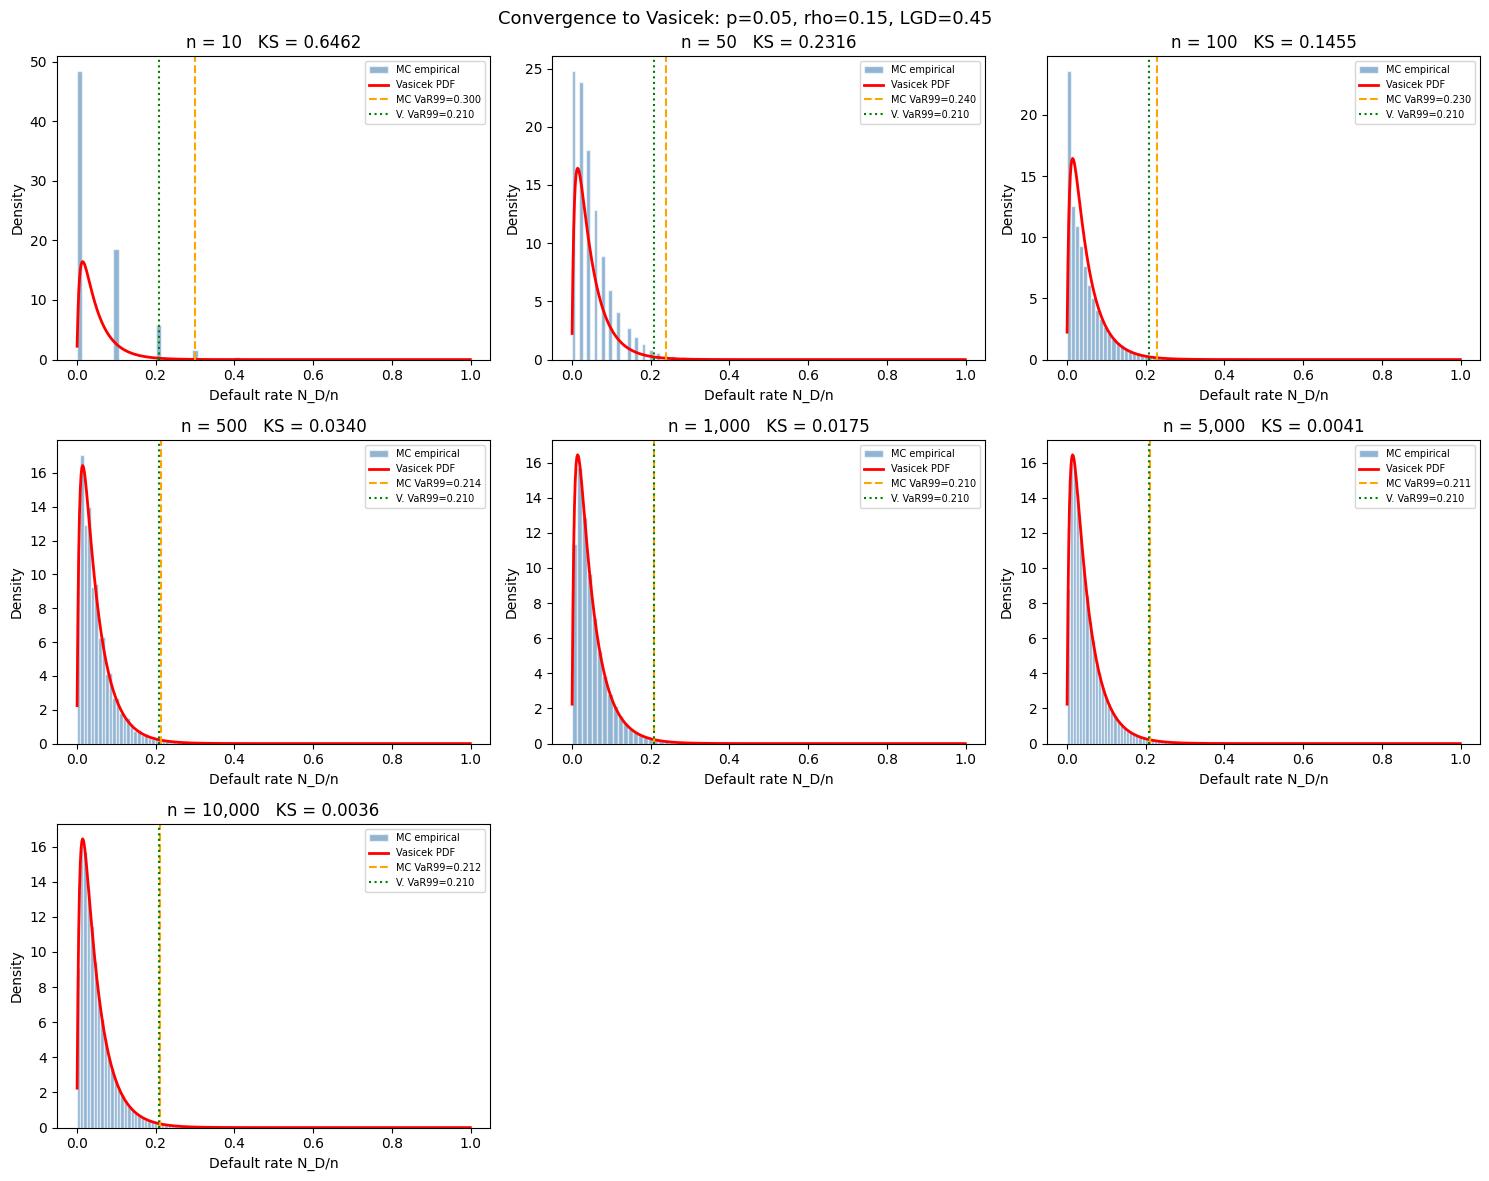

In [6]:
def convergence_study(p=0.05, rho=0.15, lgd=0.45, n_list=None, n_simulations=200_000, seed=0, plot=True):
    """
    Convergence of the empirical default rate N_D/n to the Vasicek distribution
    as n -> infinity. For each n, compares MC moments to the analytical Vasicek
    values and computes a KS test statistic.
    """
    if n_list is None:
        n_list = [10, 50, 100, 500, 1_000, 5_000, 10_000]

    vasicek = VasicekDistribution(p, rho)
    vasicek_mean, vasicek_var = vasicek.stats()
    vasicek_var99 = float(vasicek.ppf(0.99))
    results = {}

    print(f"Convergence study: p={p}, rho={rho}, LGD={lgd}, N_sim={n_simulations:,}")
    print(f"{'n':>8} | {'MC mean':>9} | {'V. mean':>9} | {'MC var':>11} | {'V. var':>11} "
          f"| {'MC VaR99':>10} | {'V. VaR99':>10} | {'KS stat':>9} | {'KS p-val':>9}")

    if plot:
        ncols = min(3, len(n_list))
        nrows = (len(n_list) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
        axes_flat = np.array(axes).flatten()
        x_grid = np.linspace(0.001, 0.999, 500)
        vasicek_pdf = vasicek.pdf(x_grid)

    for idx, n in enumerate(n_list):
        mc = GaussianFactorMC(
            ead=np.full(n, 1/n), lgd=np.full(n, lgd), pd=np.full(n, p),
            factor_weights=np.full((n, 1), np.sqrt(rho)),
            n_simulations=n_simulations, seed=seed + idx)
        mc.run()
        dr = mc.default_samples / n

        mc_mean  = float(dr.mean())
        mc_var   = float(dr.var(ddof=1))
        mc_var99 = float(np.quantile(dr, 0.99))
        ks_stat, ks_pval = stats.ks_1samp(dr, vasicek.cdf)

        results[n] = dict(mc_mean=mc_mean, mc_var=mc_var, mc_VaR99=mc_var99,
                          KS_stat=ks_stat, KS_pval=ks_pval)

        print(f"{n:>8,} | {mc_mean:>9.5f} | {vasicek_mean:>9.5f} | {mc_var:>11.7f} | {vasicek_var:>11.7f} "
              f"| {mc_var99:>10.5f} | {vasicek_var99:>10.5f} | {ks_stat:>9.5f} | {ks_pval:>9.4f}")

        if plot:
            ax = axes_flat[idx]
            ax.hist(dr, bins=60, density=True, color="steelblue",
                    alpha=0.6, edgecolor="white", label="MC empirical")
            ax.plot(x_grid, vasicek_pdf, "r-", lw=2, label="Vasicek PDF")
            ax.axvline(mc_var99, color="orange", ls="--", lw=1.5,
                       label=f"MC VaR99={mc_var99:.3f}")
            ax.axvline(vasicek_var99, color="green", ls=":", lw=1.5,
                       label=f"V. VaR99={vasicek_var99:.3f}")
            ax.set_title(f"n = {n:,}   KS = {ks_stat:.4f}")
            ax.set_xlabel("Default rate N_D/n")
            ax.set_ylabel("Density")
            ax.legend(fontsize=7)

    if plot:
        for j in range(idx + 1, len(axes_flat)):
            axes_flat[j].set_visible(False)
        fig.suptitle(f"Convergence to Vasicek: p={p}, rho={rho}, LGD={lgd}", fontsize=13)
        plt.tight_layout()
        plt.show()

    return results

cv_results = convergence_study(
    p=0.05, rho=0.15, lgd=0.45,
    n_list=[10, 50, 100, 500, 1_000, 5_000, 10_000],
    n_simulations=200_000, seed=0, plot=True)

**Comments:**

- **Mean:** $\approx p = 0.05$ for all $n$, which is consistent with $\mathbb{E}[\lambda(F)] = p$ by iterated expectations formula.
- **Variance:** substantially above the Vasicek limit for small $n$; the excess is the idiosyncratic component $\propto 1/n$. It converges to $\operatorname{Var}_\text{Vasicek} \approx 0.00194$ as $n \to \infty$.
- **$VaR_{99}$:** overestimated at small $n$ (granularity noise inflates the tail) and converges to the analytical Basel II value of approximately $0.210$.
- **KS statistic:** decreases monotonically with $n$, confirming convergence in distribution. It never reaches zero because $N_D/n$ has discrete support for any finite $n$, the KS test always rejects for high value $N_{\text{sim}}$.


### Task 2.3 Moment-based calibration of the Vasicek distribution

Consider $\hat{p} = \overline{N_D/n}$ the sample mean.

The implied correlation $\hat{\rho}$ is the correlation $\rho$ such that $\operatorname{V}[\Lambda](\rho) = \hat{\sigma}^2$ or equivalently we need to find $\rho$ such that $\Phi_2(\Phi^{-1}(p), \Phi^{-1}(p);\,\rho) - p^2 = \hat{\sigma}^2$.

But we can see that it is impossible to solve analytically this problem except for $\rho \in \{0,1 \}$ as the normal bivariate CDF $\Phi_2$ does not have a closed form in general. Then we opt for a numerical method, and here Brent's method is a good approach. Note that the function $\rho \mapsto \operatorname{V}[\Lambda](\rho)$ is strictly increasing, so that the root we are looking for is unique.


In [7]:
def calibrate_vasicek(p_hat, sigma2_hat, rho_bounds=(1e-4, 0.9999)):
    """
    Calibrate rho by matching Var[Lambda](rho) = sigma2_hat via Brent root-finding.
    Var[Lambda](rho) is strictly increasing in rho, so the root is unique.
    No closed-form inverse exists for Phi_2 w.r.t. rho, hence we proceed with the numerical approach.
    """
    def residual(rho):
        _, v = VasicekDistribution(p_hat, rho).stats()
        return v - sigma2_hat

    low, high = rho_bounds
    if residual(low) > 0:
        return float(low)
    if residual(high) < 0:
        return float(high)
    return float(brentq(residual, low, high, xtol=1e-8))


def calibration_study(p=0.05, rho_true=0.15, lgd=0.45, n=100, n_simulations=200_000, seed=42):
    """Task 2.3 Moment-based calibration for a given portfolio size n."""
    mc = GaussianFactorMC(
        ead=np.full(n, 1/n), lgd=np.full(n, lgd), pd=np.full(n, p),
        factor_weights=np.full((n, 1), np.sqrt(rho_true)),
        n_simulations=n_simulations, seed=seed)
    mc.run()
    dr = mc.default_samples / n

    p_hat = float(dr.mean())
    sigma2_hat = float(dr.var(ddof=1))
    rho_hat = calibrate_vasicek(p_hat, sigma2_hat)

    return dict(p_hat=p_hat, sigma2_hat=sigma2_hat, rho_hat=rho_hat, dr=dr)


#Step 1-3: n=100 detailed comparison
print("Task 2.3 Calibration for n=100  (p=0.05, rho_true=0.15)")

res = calibration_study(n=100, n_simulations=200_000, seed=42)
print(f"\nSample moments:   p_hat={res['p_hat']:.5f},   sigma2_hat={res['sigma2_hat']:.7f}")
print(f"Calibrated rho_hat = {res['rho_hat']:.5f}   (true rho = 0.15)")

v_true = VasicekDistribution(0.05, 0.15)
v_cal  = VasicekDistribution(res['p_hat'], res['rho_hat'])
mean_true, var_true = v_true.stats()
mean_cal,  var_cal = v_cal.stats()
dr = res['dr']

print(f"\n{'Metric':<22} {'Uncalibrated':>14} {'Calibrated':>14} {'MC empirical':>14}")
print(f"{'Mean':<22} {mean_true:>14.5f} {mean_cal:>14.5f} {res['p_hat']:>14.5f}")
print(f"{'Variance':<22} {var_true:>14.7f} {var_cal:>14.7f} {res['sigma2_hat']:>14.7f}")
for q in [0.75, 0.90, 0.95, 0.99]:
    var_q_true = float(v_true.ppf(q))
    var_q_cal = float(v_cal.ppf(q))
    var_q_mc = float(np.quantile(dr, q))
    print(f"{'VaR_'+str(q):<22} {var_q_true:>14.5f} {var_q_cal:>14.5f} {var_q_mc:>14.5f}")

#Step 4: calibration performance across portfolio sizes n
print("Task 2.3 Calibration performance across portfolio sizes n")
print(f"(p=0.05, rho_true=0.15, Nsim=50,000 per n)")
print(f"{'n':>8} | {'rho_hat':>9} | {'bias':>8} | {'cal. VaR99':>12} | {'unc. VaR99':>12} | {'MC VaR99':>10}")

ref_var99 = float(VasicekDistribution(0.05, 0.15).ppf(0.99))

for n in [50, 100, 500, 1_000, 5_000, 10_000]:
    res_n = calibration_study(p=0.05, rho_true=0.15, n=n, n_simulations=50_000, seed=0)
    v_cal_n = VasicekDistribution(res_n['p_hat'], res_n['rho_hat'])
    cal_var99 = float(v_cal_n.ppf(0.99)) #calibrated Var_99
    mc_var99 = float(np.quantile(res_n['dr'], 0.99))
    bias = res_n['rho_hat'] - 0.15
    print(f"{n:>8,} | {res_n['rho_hat']:>9.5f} | {bias:>+8.5f} | "
          f"{cal_var99:>12.5f} | {ref_var99:>12.5f} | {mc_var99:>10.5f}")

print("As n grows, rho_hat converges to the true rho=0.15 (i.e bias -> 0).")
print("Calibration is most useful for small n where granularity inflates the sample variance.")

Task 2.3 Calibration for n=100  (p=0.05, rho_true=0.15)

Sample moments:   p_hat=0.05006,   sigma2_hat=0.0023934
Calibrated rho_hat = 0.17863   (true rho = 0.15)

Metric                   Uncalibrated     Calibrated   MC empirical
Mean                          0.05000        0.05006        0.05006
Variance                    0.0019370      0.0023934      0.0023934
VaR_0.75                      0.06671        0.06684        0.07000
VaR_0.9                       0.10643        0.11187        0.11000
VaR_0.95                      0.13717        0.14750        0.15000
VaR_0.99                      0.20988        0.23287        0.22000
Task 2.3 Calibration performance across portfolio sizes n
(p=0.05, rho_true=0.15, Nsim=50,000 per n)
       n |   rho_hat |     bias |   cal. VaR99 |   unc. VaR99 |   MC VaR99
      50 |   0.20644 | +0.05644 |      0.25452 |      0.20988 |    0.24000
     100 |   0.17987 | +0.02987 |      0.23356 |      0.20988 |    0.23000
     500 |   0.15697 | +0.00697 |  

**Comments:**

For $n = 100$, the empirical default rate still has significant granularity noise:  
$\hat{\sigma}^2 \approx 0.0024 > 0.00194 = \operatorname{Var}_\text{Vasicek}(\rho=0.15)$.  
The method of moments therefore calibrates $\hat{\rho} \approx 0.18$, biased upward i.e the Vasicek model absorbs the idiosyncratic variance into a higher apparent correlation.

As a result, the calibrated VaRs are closer to the MC empirical quantiles, which themselves include granularity while the uncalibrated Vasicek underestimates the tail for small $n$.

This bias disappears as $n$ grows. Indded, for $n \geq 1{,}000$ the sample moments converge to the true Vasicek moments and $\hat{\rho} \to \rho_{\text{true}} = 0.15$.

**Limitation:** The method of moments only uses two moments. A maximum likelihood estimator over the empirical distribution of $N_D/n$ would be more efficient, particularly for small portfolios. This is the case because MLE is the estimator which has the smallest variance among all regular estimators as it reaches the Cramér-Rao bound. This is the property of asymptotic efficiency.
